# 1단계: 레시피 데이터 탐색 및 품질 분석

## 목표
- 만개의 레시피 데이터 구조 파악
- 데이터 품질 분석 (결측치, 이상치)
- 재료 데이터 패턴 분석
- GapFilling 모델에 필요한 핵심 컬럼 식별

In [23]:
# 필수 라이브러리 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings('ignore')

print("라이브러리 로딩 완료")

라이브러리 로딩 완료


## 1.1 데이터 로딩

In [24]:
# 데이터 경로 설정
DATA_PATH_2024 = '../data/recipe/TB_RECIPE_SEARCH_241226.csv'
DATA_PATH_2023 = '../data/recipe/TB_RECIPE_SEARCH-231130.csv'

# 2024년 데이터 로딩 (최신 데이터 우선)
try:
    df_2024 = pd.read_csv(DATA_PATH_2024, encoding='utf-8')
    print(f"2024년 데이터 로딩 성공: {len(df_2024):,}개 레시피")
except Exception as e:
    print(f"2024년 데이터 로딩 실패: {e}")
    df_2024 = None

# 2023년 데이터 로딩 (보조 데이터)
try:
    df_2023 = pd.read_csv(DATA_PATH_2023, encoding='utf-8')
    print(f"2023년 데이터 로딩 성공: {len(df_2023):,}개 레시피")
except Exception as e:
    print(f"2023년 데이터 로딩 실패: {e}")
    df_2023 = None

2024년 데이터 로딩 성공: 23,192개 레시피
2023년 데이터 로딩 성공: 184,991개 레시피


In [25]:
# 주 분석 데이터셋 선택 (2024년 데이터 우선)
df = df_2024 if df_2024 is not None else df_2023

print(f"분석 대상 데이터셋: {len(df):,}개 레시피")
print(f"\n컬럼 목록:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

분석 대상 데이터셋: 23,192개 레시피

컬럼 목록:
  1. RCP_SNO
  2. RCP_TTL
  3. CKG_NM
  4. RGTR_ID
  5. RGTR_NM
  6. INQ_CNT
  7. RCMM_CNT
  8. SRAP_CNT
  9. CKG_MTH_ACTO_NM
  10. CKG_STA_ACTO_NM
  11. CKG_MTRL_ACTO_NM
  12. CKG_KND_ACTO_NM
  13. CKG_IPDC
  14. CKG_MTRL_CN
  15. CKG_INBUN_NM
  16. CKG_DODF_NM
  17. CKG_TIME_NM
  18. FIRST_REG_DT
  19. RCP_IMG_URL


## 1.2 데이터 구조 분석

In [26]:
# 데이터 기본 정보
print("=" * 60)
print("데이터 기본 정보")
print("=" * 60)
df.info()

데이터 기본 정보
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23192 entries, 0 to 23191
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   RCP_SNO           23192 non-null  int64 
 1   RCP_TTL           23192 non-null  object
 2   CKG_NM            23189 non-null  object
 3   RGTR_ID           23192 non-null  object
 4   RGTR_NM           23192 non-null  object
 5   INQ_CNT           23192 non-null  int64 
 6   RCMM_CNT          23192 non-null  int64 
 7   SRAP_CNT          23192 non-null  int64 
 8   CKG_MTH_ACTO_NM   23190 non-null  object
 9   CKG_STA_ACTO_NM   23095 non-null  object
 10  CKG_MTRL_ACTO_NM  23190 non-null  object
 11  CKG_KND_ACTO_NM   23191 non-null  object
 12  CKG_IPDC          23183 non-null  object
 13  CKG_MTRL_CN       23191 non-null  object
 14  CKG_INBUN_NM      21166 non-null  object
 15  CKG_DODF_NM       23191 non-null  object
 16  CKG_TIME_NM       18112 non-null  object
 17  FI

In [27]:
# 샘플 데이터 확인
print("\n샘플 데이터 (상위 5개):")
df.head()


샘플 데이터 (상위 5개):


,RCP_SNO,RCP_TTL,CKG_NM,RGTR_ID,RGTR_NM,INQ_CNT,RCMM_CNT,SRAP_CNT,CKG_MTH_ACTO_NM,CKG_STA_ACTO_NM,CKG_MTRL_ACTO_NM,CKG_KND_ACTO_NM,CKG_IPDC,CKG_MTRL_CN,CKG_INBUN_NM,CKG_DODF_NM,CKG_TIME_NM,FIRST_REG_DT,RCP_IMG_URL
0,7016813,멸치육수 소고기 떡국 만드는법,소고기떡국,ranch6356,반이짝이,743,0,2,끓이기,명절,소고기,국/탕,새해가 되면 뜨끈한 떡국 한 그릇이 생각나는데요. 오늘은 집에서 간단하게 요리할 수...,[재료] 떡국떡400g| 다진소고기100g| 멸치육수800ml| 대...,2인분,초급,NaN,20240101000857,https://recipe1.ezmember.co.kr/cache/recipe/20...
1,7016814,#수육용삼겹살 #된장수육만들기 #일상먹거리 #무생채와함께먹는된장수육,된장수육,kstencil,강철새잎,1396,0,1,삶기,술안주,돼지고기,메인반찬,수육용 삼겹살을 사다가 된장과 술을 넣고 일상먹거리 수육한접시를 만들어 주었습니다....,[재료] 돼지고기 수육용삼겹살500g| 된장1.5큰술| 술4큰술| ...,2인분,아무나,2시간이내,20240101002917,https://recipe1.ezmember.co.kr/cache/recipe/20...
2,7016815,우거지감자탕 뼈해장국 끓이는법,우거지감자탕,87771622,김한솔,4008,0,29,끓이기,해장,돼지고기,국/탕,까다로운 남편의 입맛을 맞추기위해 여러번 시도끝에 만들어낸 최적의 레시피입니다. 한...,[재료] 돼지등뼈1.5kg| 양파1/2개| 감자1개| 대파1대...,4인분,중급,2시간이내,20240101020501,https://recipe1.ezmember.co.kr/cache/recipe/20...
3,7016816,만두전골 레시피 백종원 만두 전골요리 뜨끈하고 진한 국물이 일품,만두전골,aeaelove,춤추는루나,6350,0,6,끓이기,손님접대,가공식품류,국/탕,속이 꽉 찬 만두가 듬뿍 푸짐한 백종원 만두전골 만두전골 레시피 만두 요리는 다양한...,[재료] 만두12개| 청경채3개| 양파1/2개| 대파1/2개|...,4인분,초급,60분이내,20240101073609,https://recipe1.ezmember.co.kr/cache/recipe/20...
4,7016817,새해 통삼겹살 무수분 보쌈 삶는법 백종원 보쌈 마늘소스 만들기,무수분보쌈,aeaelove,춤추는루나,1829,0,6,삶기,손님접대,돼지고기,메인반찬,촉촉하고 부드러운 통삼겹살 무수분 보쌈 삶는법 무수분 보쌈 삶는 시간 백종원 보쌈 ...,[재료] 통삼겹살600g| 양파1개| 못난이 사과 小2개| 대파2...,4인분,초급,90분이내,20240101074507,https://recipe1.ezmember.co.kr/cache/recipe/20...


In [28]:
# 핵심 컬럼 정의 (GapFilling 모델에 필요한 컬럼)
CORE_COLUMNS = {
    'RCP_SNO': '레시피 일련번호 (PK)',
    'RCP_TTL': '레시피 제목',
    'CKG_NM': '요리명',
    'CKG_MTRL_CN': '재료 내용 (핵심)',
    'INQ_CNT': '조회수 (인기도)',
    'RCMM_CNT': '추천수',
    'SRAP_CNT': '스크랩수',
    'CKG_KND_ACTO_NM': '요리 종류',
    'CKG_DODF_NM': '난이도',
    'CKG_TIME_NM': '조리 시간'
}

print("GapFilling 모델 핵심 컬럼:")
for col, desc in CORE_COLUMNS.items():
    exists = "✓" if col in df.columns else "✗"
    print(f"  {exists} {col}: {desc}")

GapFilling 모델 핵심 컬럼:
  ✓ RCP_SNO: 레시피 일련번호 (PK)
  ✓ RCP_TTL: 레시피 제목
  ✓ CKG_NM: 요리명
  ✓ CKG_MTRL_CN: 재료 내용 (핵심)
  ✓ INQ_CNT: 조회수 (인기도)
  ✓ RCMM_CNT: 추천수
  ✓ SRAP_CNT: 스크랩수
  ✓ CKG_KND_ACTO_NM: 요리 종류
  ✓ CKG_DODF_NM: 난이도
  ✓ CKG_TIME_NM: 조리 시간


## 1.3 결측치 분석

In [29]:
# 결측치 분석
missing_stats = pd.DataFrame({
    '컬럼명': df.columns,
    '결측치 수': df.isnull().sum().values,
    '결측치 비율(%)': (df.isnull().sum() / len(df) * 100).round(2).values
})

missing_stats = missing_stats.sort_values('결측치 비율(%)', ascending=False)
print("결측치 현황:")
missing_stats

결측치 현황:


,컬럼명,결측치 수,결측치 비율(%)
16,CKG_TIME_NM,5080,21.90
14,CKG_INBUN_NM,2026,8.74
9,CKG_STA_ACTO_NM,97,0.42
12,CKG_IPDC,9,0.04
18,RCP_IMG_URL,9,0.04
2,CKG_NM,3,0.01
8,CKG_MTH_ACTO_NM,2,0.01
10,CKG_MTRL_ACTO_NM,2,0.01
0,RCP_SNO,0,0.00
1,RCP_TTL,0,0.00


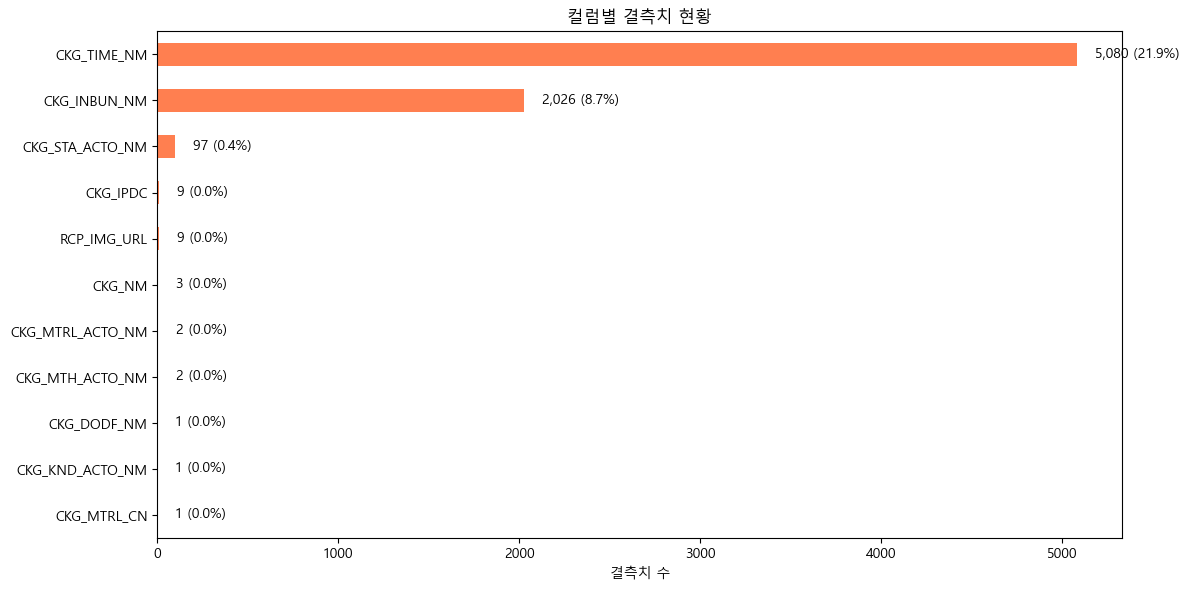

In [30]:
# 결측치 시각화
fig, ax = plt.subplots(figsize=(12, 6))

missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=True)

if len(missing_data) > 0:
    missing_data.plot(kind='barh', ax=ax, color='coral')
    ax.set_xlabel('결측치 수')
    ax.set_title('컬럼별 결측치 현황')
    
    for i, v in enumerate(missing_data.values):
        ax.text(v + 100, i, f'{v:,} ({v/len(df)*100:.1f}%)', va='center')
else:
    ax.text(0.5, 0.5, '결측치 없음', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

## 1.4 재료 데이터 (CKG_MTRL_CN) 심층 분석

In [31]:
# 재료 컬럼 존재 여부 확인
INGREDIENT_COL = 'CKG_MTRL_CN'

if INGREDIENT_COL not in df.columns:
    # 다른 가능한 컬럼명 탐색
    possible_cols = [col for col in df.columns if 'MTRL' in col or '재료' in col]
    print(f"'{INGREDIENT_COL}' 컬럼이 없습니다.")
    print(f"가능한 재료 관련 컬럼: {possible_cols}")
else:
    print(f"재료 컬럼 '{INGREDIENT_COL}' 확인됨")

재료 컬럼 'CKG_MTRL_CN' 확인됨


In [32]:
# 재료 데이터 샘플 확인
print("재료 데이터 샘플 (10개):")
print("=" * 80)

sample_ingredients = df[INGREDIENT_COL].dropna().head(10)
for i, ing in enumerate(sample_ingredients, 1):
    print(f"\n[{i}] {ing[:200]}..." if len(str(ing)) > 200 else f"\n[{i}] {ing}")

재료 데이터 샘플 (10개):

[1] [재료] 떡국떡400g| 다진소고기100g| 멸치육수800ml| 대파1/3대| 계란2개| 참기름1T| 국간장1T| 참기름1/2T| 다진마늘1t| 소금| 김가루약간

[2] [재료] 돼지고기 수육용삼겹살500g| 된장1.5큰술| 술4큰술| 홍어무침| 무생채| 콩나물무침

[3] [재료] 돼지등뼈1.5kg| 양파1/2개| 감자1개| 대파1대| 알배기배추1/2개| 청양고추2개| 깻잎10~15장 [양념] 된장2T| 고추장2T| 다진마늘1T| 간장3T| 고춧가루3T| 액젓3T| 다진생강1t| 다시다1t| 들깨가루3T

[4] [재료] 만두12개| 청경채3개| 양파1/2개| 대파1/2개| 느타리버섯100g| 홍고추약간 [만두전골 육수] 코인 육수2개| 다시마4개| 물1L [전골요리 양념장] 고춧가루1T| 국간장2T| 참치 액1T| 다진 마늘1T| 통후추20바퀴

[5] [재료] 통삼겹살600g| 양파1개| 못난이 사과 小2개| 대파2대| 마늘8개| 생강가루| 월계수 잎4~5장| 통후추조금| 맛술1/2컵 [보쌈 마늘소스 양념] 다진 마늘4T| 설탕2T| 꿀2T| 레몬즙3T| 올리브유0.5T

[6] [재료] 국산콩 손두부600g| 한알 육수2알| 새우젓 양념2큰술| 고춧가루1큰술| 다진마늘1/2큰술| 파7큰술| 들기름3큰술| 물700ml [새우젓양념재료] 육젓5큰술| 고춧가루3큰술| 다진마늘2큰술

[7] [재료] 돼지 등갈비550g| 올리브오일2큰술| 통깨살짝 [등갈비삶기] 물1.2L| 월계수잎3~4장| 통후추0.3큰술|

In [33]:
# 재료 데이터 패턴 분석
def analyze_ingredient_pattern(text):
    """재료 텍스트의 패턴을 분석하는 함수"""
    if pd.isna(text):
        return {'type': 'null', 'separator': None, 'has_section': False}
    
    text = str(text)
    
    # 섹션 태그 확인 ([재료], [양념], [소스] 등)
    has_section = bool(re.search(r'\[.*?\]', text))
    
    # 구분자 패턴 분석
    if '|' in text:
        separator = '|'
    elif ',' in text:
        separator = ','
    elif '\n' in text:
        separator = 'newline'
    else:
        separator = 'unknown'
    
    return {
        'type': 'valid',
        'separator': separator,
        'has_section': has_section,
        'length': len(text)
    }

# 패턴 분석 실행
pattern_results = df[INGREDIENT_COL].apply(analyze_ingredient_pattern)
pattern_df = pd.DataFrame(pattern_results.tolist())

print("재료 데이터 패턴 분석 결과:")
print(f"\n구분자 유형 분포:")
print(pattern_df['separator'].value_counts())

print(f"\n섹션 태그 포함 비율: {pattern_df['has_section'].mean()*100:.1f}%")

재료 데이터 패턴 분석 결과:

구분자 유형 분포:
separator
|          22911
unknown      280
Name: count, dtype: int64

섹션 태그 포함 비율: 100.0%


In [34]:
# 재료 개수 분포 분석
def count_ingredients(text):
    """재료 텍스트에서 재료 개수를 추출하는 함수"""
    if pd.isna(text):
        return 0
    
    text = str(text)
    
    # 섹션 태그 제거
    text = re.sub(r'\[.*?\]', '', text)
    
    # | 구분자로 분리
    if '|' in text:
        ingredients = [i.strip() for i in text.split('|') if i.strip()]
    else:
        ingredients = [text.strip()] if text.strip() else []
    
    return len(ingredients)

df['ingredient_count'] = df[INGREDIENT_COL].apply(count_ingredients)

print("레시피당 재료 개수 통계:")
print(df['ingredient_count'].describe())

레시피당 재료 개수 통계:
count    23192.000000
mean         8.563901
std          3.779093
min          0.000000
25%          6.000000
50%          8.000000
75%         11.000000
max         52.000000
Name: ingredient_count, dtype: float64


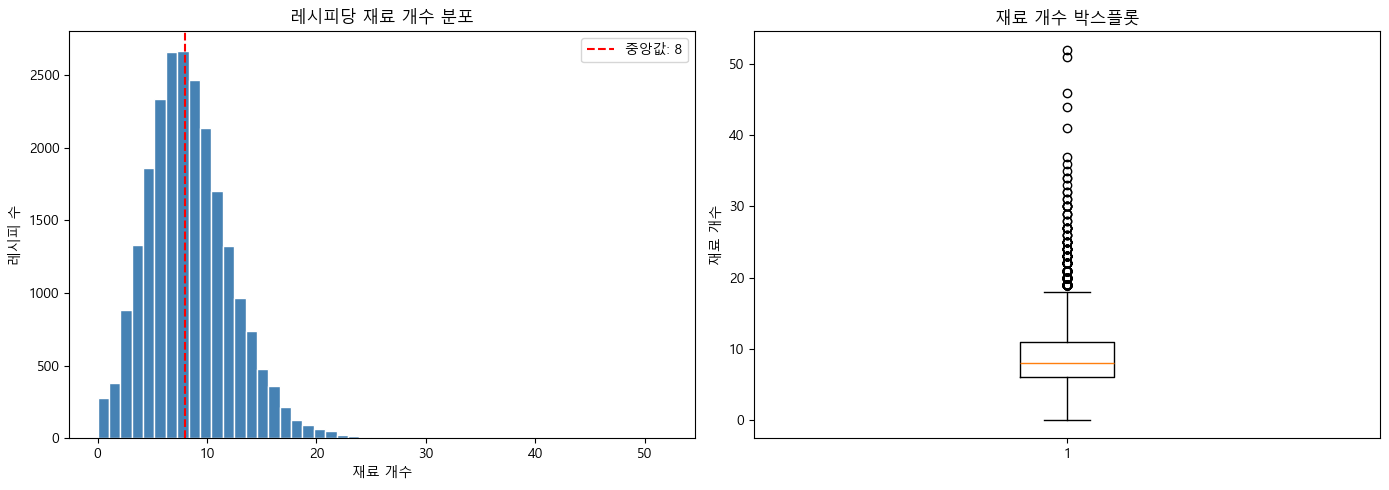

In [35]:
# 재료 개수 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(df['ingredient_count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('재료 개수')
axes[0].set_ylabel('레시피 수')
axes[0].set_title('레시피당 재료 개수 분포')
axes[0].axvline(df['ingredient_count'].median(), color='red', linestyle='--', label=f'중앙값: {df["ingredient_count"].median():.0f}')
axes[0].legend()

# 박스플롯
axes[1].boxplot(df['ingredient_count'].dropna(), vert=True)
axes[1].set_ylabel('재료 개수')
axes[1].set_title('재료 개수 박스플롯')

plt.tight_layout()
plt.show()

## 1.5 인기도 지표 분석

In [36]:
# 인기도 관련 컬럼 확인
POPULARITY_COLS = ['INQ_CNT', 'RCMM_CNT', 'SRAP_CNT']

available_pop_cols = [col for col in POPULARITY_COLS if col in df.columns]
print(f"사용 가능한 인기도 컬럼: {available_pop_cols}")

if available_pop_cols:
    print("\n인기도 지표 통계:")
    print(df[available_pop_cols].describe())

사용 가능한 인기도 컬럼: ['INQ_CNT', 'RCMM_CNT', 'SRAP_CNT']

인기도 지표 통계:
            INQ_CNT      RCMM_CNT      SRAP_CNT
count  23192.000000  23192.000000  23192.000000
mean     947.683641      0.000647      7.845033
std     1940.419722      0.025424     30.416332
min        8.000000      0.000000      0.000000
25%      159.000000      0.000000      1.000000
50%      377.000000      0.000000      3.000000
75%      934.000000      0.000000      6.000000
max    60777.000000      1.000000   1235.000000


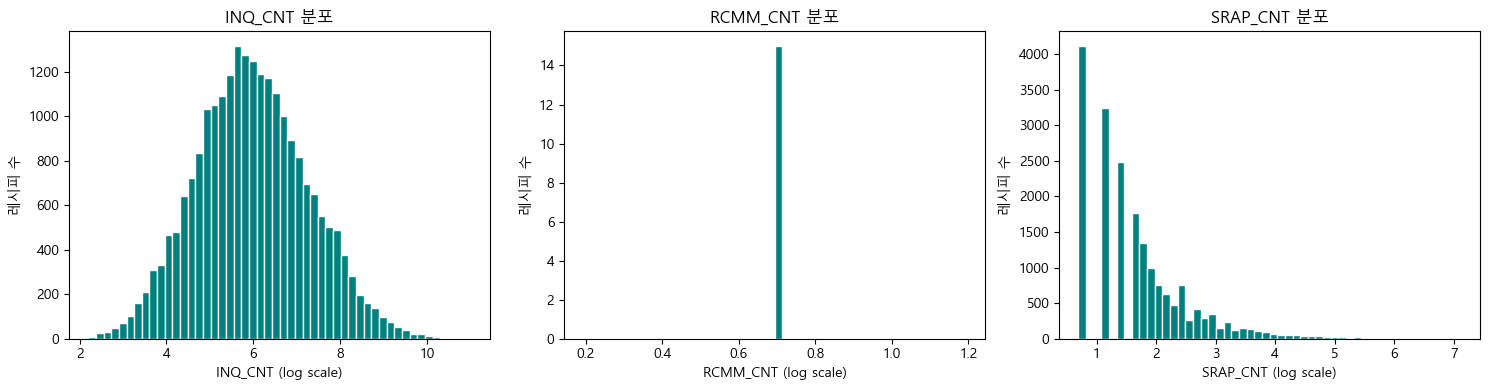

In [37]:
# 인기도 지표 분포 시각화
if available_pop_cols:
    fig, axes = plt.subplots(1, len(available_pop_cols), figsize=(5*len(available_pop_cols), 4))
    
    if len(available_pop_cols) == 1:
        axes = [axes]
    
    for ax, col in zip(axes, available_pop_cols):
        # 로그 스케일로 히스토그램
        data = df[col].dropna()
        data = data[data > 0]  # 0보다 큰 값만
        
        ax.hist(np.log1p(data), bins=50, color='teal', edgecolor='white')
        ax.set_xlabel(f'{col} (log scale)')
        ax.set_ylabel('레시피 수')
        ax.set_title(f'{col} 분포')
    
    plt.tight_layout()
    plt.show()

In [38]:
# 인기도 종합 점수 계산
if available_pop_cols:
    # 각 지표 정규화 (0-1 스케일)
    for col in available_pop_cols:
        max_val = df[col].max()
        if max_val > 0:
            df[f'{col}_norm'] = df[col] / max_val
        else:
            df[f'{col}_norm'] = 0
    
    # 종합 인기도 점수 (가중 평균)
    # 조회수(0.5) + 추천수(0.3) + 스크랩수(0.2)
    weights = {'INQ_CNT_norm': 0.5, 'RCMM_CNT_norm': 0.3, 'SRAP_CNT_norm': 0.2}
    
    df['popularity_score'] = 0
    for col, weight in weights.items():
        if col in df.columns:
            df['popularity_score'] += df[col].fillna(0) * weight
    
    print("종합 인기도 점수 통계:")
    print(df['popularity_score'].describe())
    
    print("\n인기 레시피 TOP 10:")
    top_recipes = df.nlargest(10, 'popularity_score')[['RCP_TTL', 'CKG_NM', 'popularity_score'] + available_pop_cols]
    display(top_recipes)

종합 인기도 점수 통계:
count    23192.000000
mean         0.009261
std          0.020098
min          0.000066
25%          0.001651
50%          0.003730
75%          0.009020
max          0.544021
Name: popularity_score, dtype: float64

인기 레시피 TOP 10:


,RCP_TTL,CKG_NM,popularity_score,INQ_CNT,RCMM_CNT,SRAP_CNT
2852,들기름 막국수 레시피 들기름 막국수 간단하게 만들기,들기름막국수,0.544021,26709,1,150
19487,실패할일 없는 김장김치양념 /절임배추20kg/ 김장김치 양념비율 황금레시피 /김장담그기,김장김치,0.508421,60777,0,52
5398,국물 닭볶음탕 황금레시피,국물닭볶음탕,0.379946,45495,0,35
12144,양파요리 양파장아찌 담그는법 만들기,양파장아찌,0.374479,8876,1,9
13617,사먹지 마세요!!! 끓이지 않고 손쉽게 삭힌고추 만드는법 삭힌고추무침 레시피,삭힌고추무침,0.351717,38540,0,214
4346,편스토랑 류수영 고등어조림 레시피 어남선생 고등어무조림 생선조림 양념장,고등어무조림,0.323712,34821,0,230
3748,새우전 만들기 새우부추전 레시피,새우부추전,0.316535,1754,1,13
732,다이어트식으로 딱 알배추 두부말이구이,알배추두부말이구이,0.313365,13780,0,1235
1295,소고기 미역국 맛있게 끓이는 방법,소고기미역국,0.313147,1224,1,19
2145,간단하고 든든해서 혼밥메뉴로 한그릇 뚝딱~ 팽이달걀덮밥,팽이달걀덮밥,0.312887,17462,0,1045


## 1.6 요리 종류별 분석

요리 종류별 레시피 수:
CKG_KND_ACTO_NM
밑반찬         5025
메인반찬        4276
밥/죽/떡       2721
국/탕         2193
기타          1424
면/만두        1334
디저트          943
빵            869
찌개           798
샐러드          740
차/음료/술       667
김치/젓갈/장류     609
양식           553
퓨전           416
양념/소스/잼      292
과자           205
스프           126
Name: count, dtype: int64


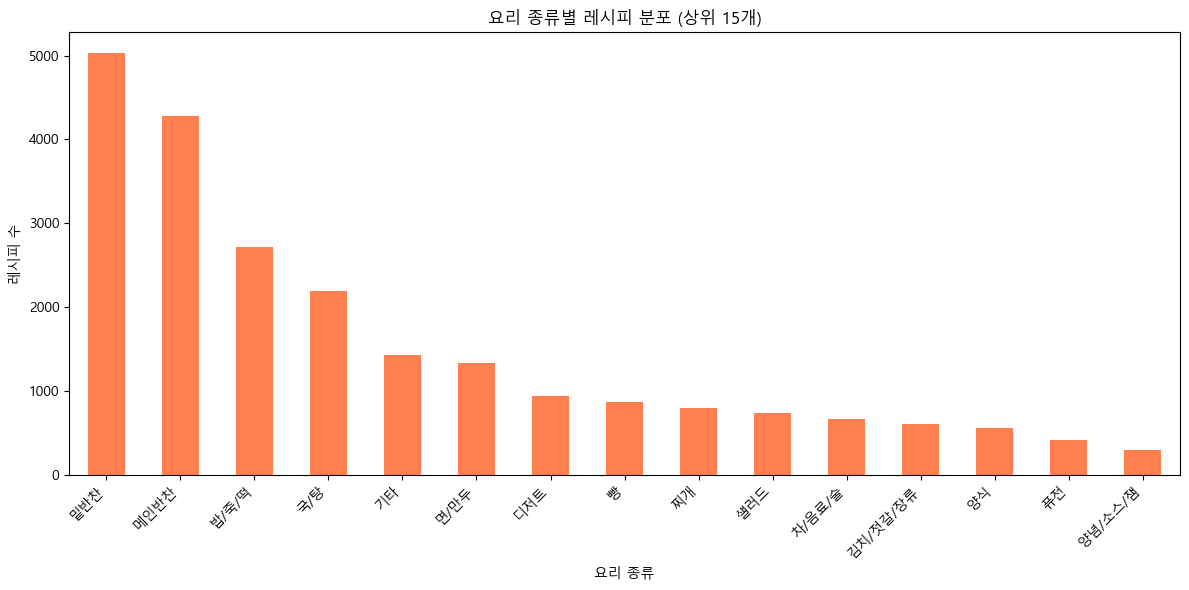

In [39]:
# 요리 종류 분포
CATEGORY_COL = 'CKG_KND_ACTO_NM'

if CATEGORY_COL in df.columns:
    category_counts = df[CATEGORY_COL].value_counts()
    
    print("요리 종류별 레시피 수:")
    print(category_counts)
    
    # 시각화
    fig, ax = plt.subplots(figsize=(12, 6))
    category_counts.head(15).plot(kind='bar', ax=ax, color='coral')
    ax.set_xlabel('요리 종류')
    ax.set_ylabel('레시피 수')
    ax.set_title('요리 종류별 레시피 분포 (상위 15개)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"'{CATEGORY_COL}' 컬럼이 존재하지 않습니다.")

## 1.7 난이도 및 조리시간 분석

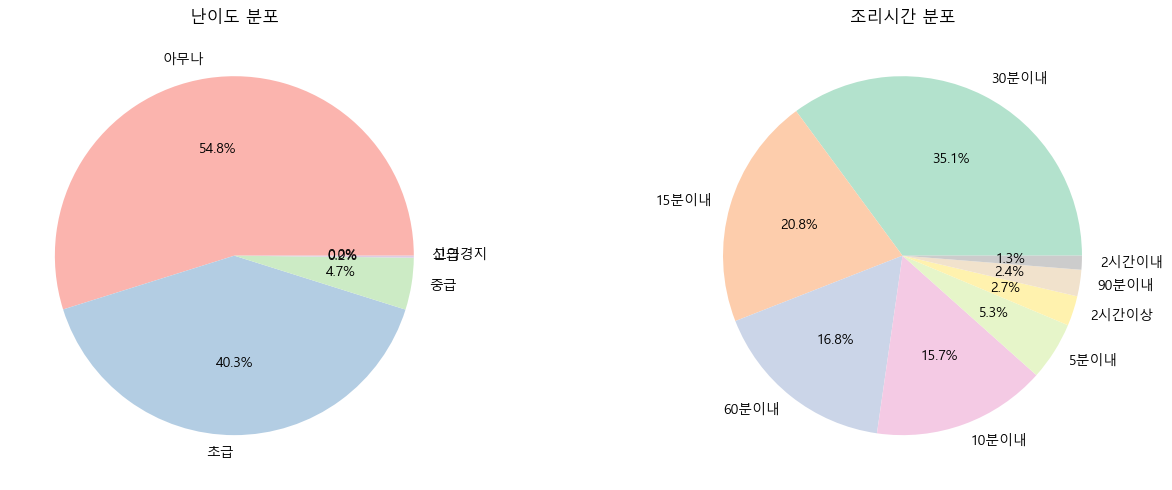

In [40]:
# 난이도 분포
DIFFICULTY_COL = 'CKG_DODF_NM'
TIME_COL = 'CKG_TIME_NM'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 난이도 분포
if DIFFICULTY_COL in df.columns:
    difficulty_counts = df[DIFFICULTY_COL].value_counts()
    axes[0].pie(difficulty_counts.values, labels=difficulty_counts.index, autopct='%1.1f%%', colors=plt.cm.Pastel1.colors)
    axes[0].set_title('난이도 분포')
else:
    axes[0].text(0.5, 0.5, '난이도 데이터 없음', ha='center', va='center')

# 조리시간 분포
if TIME_COL in df.columns:
    time_counts = df[TIME_COL].value_counts()
    axes[1].pie(time_counts.values, labels=time_counts.index, autopct='%1.1f%%', colors=plt.cm.Pastel2.colors)
    axes[1].set_title('조리시간 분포')
else:
    axes[1].text(0.5, 0.5, '조리시간 데이터 없음', ha='center', va='center')

plt.tight_layout()
plt.show()

## 1.8 데이터 품질 종합 평가

In [41]:
# 데이터 품질 점수 계산
quality_metrics = {
    '총 레시피 수': len(df),
    '재료 데이터 완전성(%)': (1 - df[INGREDIENT_COL].isna().mean()) * 100,
    '평균 재료 개수': df['ingredient_count'].mean(),
    '재료 0개 레시피 수': (df['ingredient_count'] == 0).sum(),
    '인기도 데이터 완전성(%)': (1 - df[available_pop_cols].isna().any(axis=1).mean()) * 100 if available_pop_cols else 0
}

print("=" * 60)
print("데이터 품질 종합 평가")
print("=" * 60)
for metric, value in quality_metrics.items():
    if isinstance(value, float):
        print(f"{metric}: {value:.2f}")
    else:
        print(f"{metric}: {value:,}")

데이터 품질 종합 평가
총 레시피 수: 23,192
재료 데이터 완전성(%): 100.00
평균 재료 개수: 8.56
재료 0개 레시피 수: 1
인기도 데이터 완전성(%): 100.00


In [42]:
# GapFilling 모델 적합성 평가
print("\n" + "=" * 60)
print("GapFilling 모델 적합성 평가")
print("=" * 60)

# 유효 레시피 필터링 (재료 3개 이상)
valid_recipes = df[df['ingredient_count'] >= 3]
print(f"\n유효 레시피 수 (재료 3개 이상): {len(valid_recipes):,}개 ({len(valid_recipes)/len(df)*100:.1f}%)")

# 인기 레시피 (상위 20%)
if 'popularity_score' in df.columns:
    popularity_threshold = df['popularity_score'].quantile(0.8)
    popular_recipes = df[df['popularity_score'] >= popularity_threshold]
    print(f"인기 레시피 수 (상위 20%): {len(popular_recipes):,}개")

print("\n✓ 데이터 탐색 완료!")
print("\n다음 단계: 02_ingredient_parsing.ipynb에서 재료 파싱 및 정규화 진행")


GapFilling 모델 적합성 평가

유효 레시피 수 (재료 3개 이상): 22,529개 (97.1%)
인기 레시피 수 (상위 20%): 4,639개

✓ 데이터 탐색 완료!

다음 단계: 02_ingredient_parsing.ipynb에서 재료 파싱 및 정규화 진행


## 1.9 분석 데이터 저장

In [43]:
# 분석 결과를 다음 노트북에서 사용할 수 있도록 저장
import os

OUTPUT_DIR = '../data/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 핵심 컬럼만 추출하여 저장
core_cols = [col for col in ['RCP_SNO', 'RCP_TTL', 'CKG_NM', 'CKG_MTRL_CN', 
                              'INQ_CNT', 'RCMM_CNT', 'SRAP_CNT', 'CKG_KND_ACTO_NM',
                              'CKG_DODF_NM', 'CKG_TIME_NM', 'ingredient_count', 'popularity_score']
             if col in df.columns]

df_core = df[core_cols].copy()
df_core.to_csv(f'{OUTPUT_DIR}/recipes_analyzed.csv', index=False, encoding='utf-8-sig')

print(f"분석 데이터 저장 완료: {OUTPUT_DIR}/recipes_analyzed.csv")
print(f"저장된 레시피 수: {len(df_core):,}개")
print(f"저장된 컬럼: {core_cols}")

분석 데이터 저장 완료: ../data/processed/recipes_analyzed.csv
저장된 레시피 수: 23,192개
저장된 컬럼: ['RCP_SNO', 'RCP_TTL', 'CKG_NM', 'CKG_MTRL_CN', 'INQ_CNT', 'RCMM_CNT', 'SRAP_CNT', 'CKG_KND_ACTO_NM', 'CKG_DODF_NM', 'CKG_TIME_NM', 'ingredient_count', 'popularity_score']
